In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
from tqdm import tqdm
from scipy.spatial import distance
import os

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define pockets
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
pockets = sorted(os.listdir(PATH_TO_DOCKING_RESULTS))[:10]

# Load labels
root = '../../../Documents/mtb-targeted-protein-degradation/scripts'
PATH_TO_PROBS = os.path.join(root, "..", "processed", "unidock_docking", "inference_probs")
labels = np.array(pickle.load(open(os.path.join(PATH_TO_PROBS, "success_mols.pkl"), "rb")))

# Load probabilities
pocket_to_all_probs = {}
# pockets_to_discard = []
for c, pocket in tqdm(enumerate(pockets)):
    probs = np.load(os.path.join(PATH_TO_PROBS, f"{pocket}_bin_01.npz"))["arr_0"]
    pocket_to_all_probs[pocket] = probs
    # if len(set(probs)) == 1:
    #     pockets_to_discard.append(pocket)

# # Remove those pockets having no variance at inference time
# pockets = [i for i in pockets if i not in pockets_to_discard]

10it [00:02,  4.85it/s]


In [3]:
# Prepare matrix
M_1 = np.array([pocket_to_all_probs[p] for p in pockets]).T
M_2 = np.column_stack([pocket_to_all_probs[p] for p in pockets])

In [7]:
np.all(M_1 == M_2)

np.True_

In [3]:
# Prepare matrix
M = np.array([pocket_to_all_probs[p] for p in pockets]).T

# # Prepare matrix
# M = np.column_stack([pocket_to_all_probs[p] for p in pockets])
# del pocket_to_all_probs

print("Normalizing by columns...")

# Calculate means
means_1 = np.mean(M, axis=0, keepdims=True)

# Calculate stds
stds_1 = np.std(M, axis=0, keepdims=True)

# Z-score (1)
M -= means_1
M /= stds_1

print("Normalizing by rows...")

# Calculate means
means_2 = np.mean(M, axis=1, keepdims=True)

# Calculate stds
stds_2 = np.std(M, axis=1, keepdims=True)

# Z-score (2)
M -= means_2
M /= stds_2

Normalizing by columns...
Normalizing by rows...


In [4]:
M  # transposing

array([[ 0.04638589, -0.06123437, -0.08266211, ..., -0.05894643,
        -0.01470616,  0.27188522],
       [ 0.05519435, -0.05114824, -0.07522804, ..., -0.10682926,
        -0.02681697,  0.20449375],
       [ 0.02208271, -0.03554416, -0.1036066 , ..., -0.09079921,
         0.08218566,  0.34407988],
       ...,
       [ 0.04715717, -0.07038346, -0.03148384, ..., -0.12637228,
         0.03441738,  0.14534265],
       [ 0.07961773, -0.05388891, -0.06147559, ..., -0.11892333,
        -0.01285016,  0.15323702],
       [-0.17730416, -0.2527563 , -0.29557505, ..., -0.27079225,
         0.48498145,  2.1169763 ]], shape=(9556875, 276), dtype=float32)

In [4]:
M  # column stacking

array([[-0.08178622, -0.16352548, -0.20090163, ...,  0.29322353,
        -0.651097  ,  0.43179318],
       [-0.07572157, -0.15691784, -0.19631751, ...,  0.2598927 ,
        -0.6616404 ,  0.38531825],
       [-0.09596822, -0.14236723, -0.21311477, ...,  0.2741906 ,
        -0.57968324,  0.4876357 ],
       ...,
       [-0.08231213, -0.17102848, -0.16562726, ...,  0.24575338,
        -0.6185017 ,  0.34192118],
       [-0.05901052, -0.15903147, -0.1866543 , ...,  0.25197023,
        -0.6526176 ,  0.34827197],
       [-0.21082012, -0.28668475, -0.34194425, ..., -0.01442156,
         0.09371737,  2.2137377 ]], shape=(9556875, 276), dtype=float32)

In [5]:
TOPs = [100, 1000, 10000, 100000]
l = len(pockets)
HIT_OVERLAP = {i: {} for i in TOPs}

pocket_to_inds = {}
# For each pocket
for c, pocket in tqdm(enumerate(pockets)):
    # Get indices that sort z-scored probs - limited to MAX(TOPs)
    ind = np.argsort(M[:, c])[::-1][:max(TOPs)]
    pocket_to_inds[pocket] = np.array(ind, dtype='int32')

276it [03:10,  1.45it/s]


In [6]:
# For each pocket1
for c1, pocket1 in tqdm(enumerate(pockets)):
    # For each pocket2
    for c2, pocket2 in enumerate(pockets[c1:]):
        # For each hit set
        for c3, TOP in enumerate(TOPs):
            h1 = pocket_to_inds[pocket1][:TOP]
            h2 = pocket_to_inds[pocket2][:TOP]
            HIT_OVERLAP[TOP][(pocket1, pocket2)] = np.intersect1d(h1, h2).size
            HIT_OVERLAP[TOP][(pocket2, pocket1)] = HIT_OVERLAP[TOP][(pocket1, pocket2)]

276it [01:30,  3.06it/s]


In [7]:
# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))
pocket_to_coords = {}

for file, pocket_numb, coord in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'], pocket_detection_data['Pocket centroid coordinate (x y z)']):
    
    # Prepare labels
    label = file.replace(".pdb", "") + "_pocket_" + str(pocket_numb)

    # Create mappings
    pocket_to_coords[label] = np.array(coord.split(), dtype=float)

In [8]:
diff_protein = {i: {} for i in TOPs}
same_protein = {i: {} for i in TOPs}
same_pocket = {i: {} for i in TOPs}

for c, pocket1 in tqdm(enumerate(pockets)):
    for pocket2 in pockets[c+1:]:

        # Define pair
        pair = (pocket1, pocket2)
        
        # If the protein is different
        if pocket1.split("_")[1] != pocket2.split("_")[1]:
            for TOP in TOPs:
                diff_protein[TOP][pair] = HIT_OVERLAP[TOP][pair]

        else:

            # Calculate distance
            d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])

            # If the pocket is the same
            if d < 6.14:
                for TOP in TOPs:
                    same_pocket[TOP][pair] = HIT_OVERLAP[TOP][pair]

            # If the pocket is not the same
            else:
                for TOP in TOPs:
                    same_protein[TOP][pair] = HIT_OVERLAP[TOP][pair]

276it [00:00, 1706.47it/s]


In [9]:
# for TOP in TOPs:

#     plt.figure(figsize=(3.5, 2))

#     bins = np.linspace(0, TOP*0.4, 100)
#     plt.hist(np.array(list(diff_protein[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=f'Different protein ({len(diff_protein[TOP])})', zorder=2, density=True)
#     plt.hist(np.array(list(same_protein[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=f'Same prot - diff pocket ({len(same_protein[TOP])})', zorder=2, density=True, alpha=0.85)
#     plt.hist(np.array(list(same_pocket[TOP].values())), bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=f'Same pocket ({len(same_pocket[TOP])})', zorder=2, density=True, alpha=0.75)

#     title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
#     plt.title(title, pad=10)
#     plt.gca().set_yticklabels([])
#     plt.xlabel("Number of hits", labelpad=10)
#     plt.ylabel("Density", labelpad=8)
#     plt.grid(linestyle='--', zorder=-2)
#     l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
#     l.get_frame().set_linewidth(0.6)
#     plt.show()

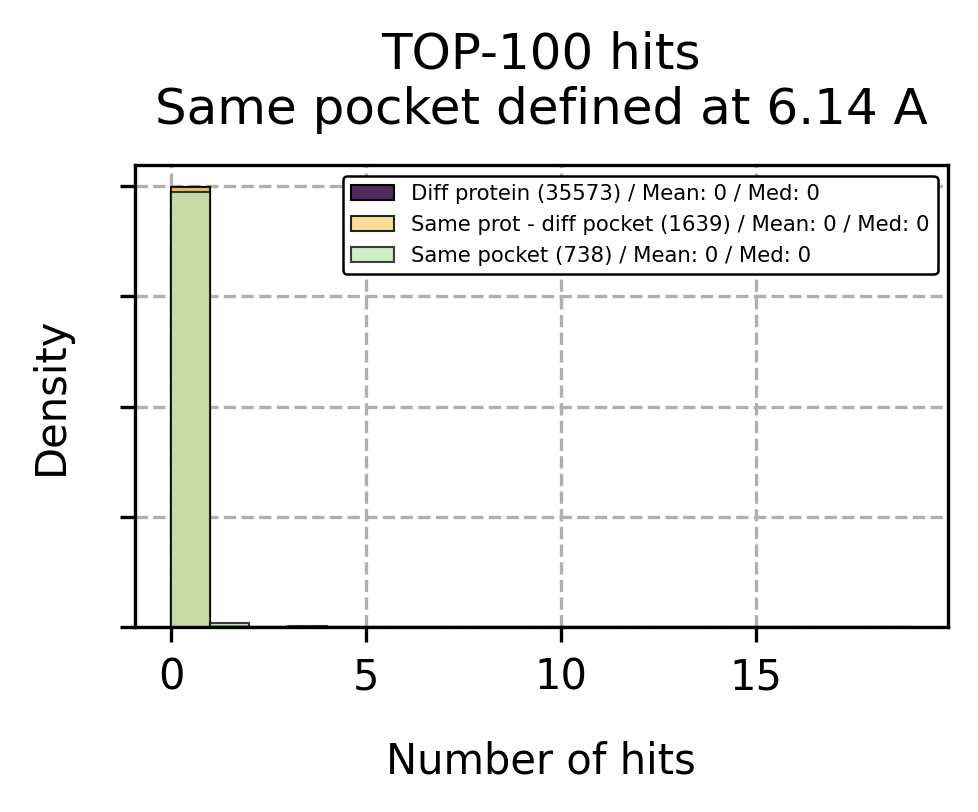

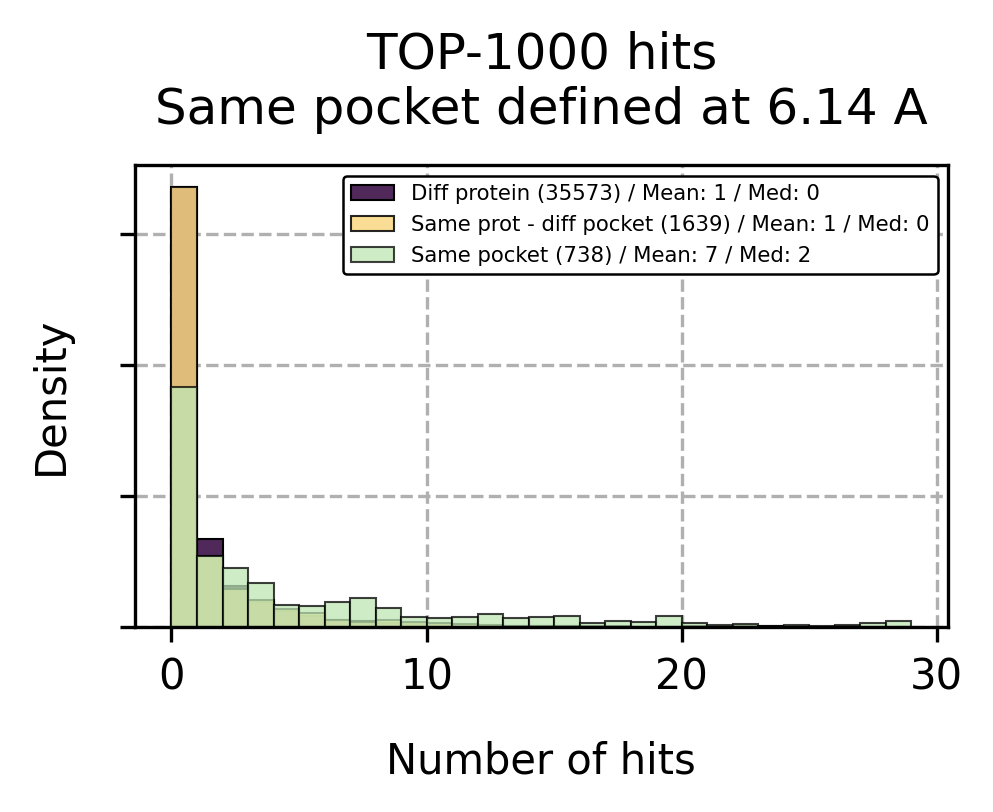

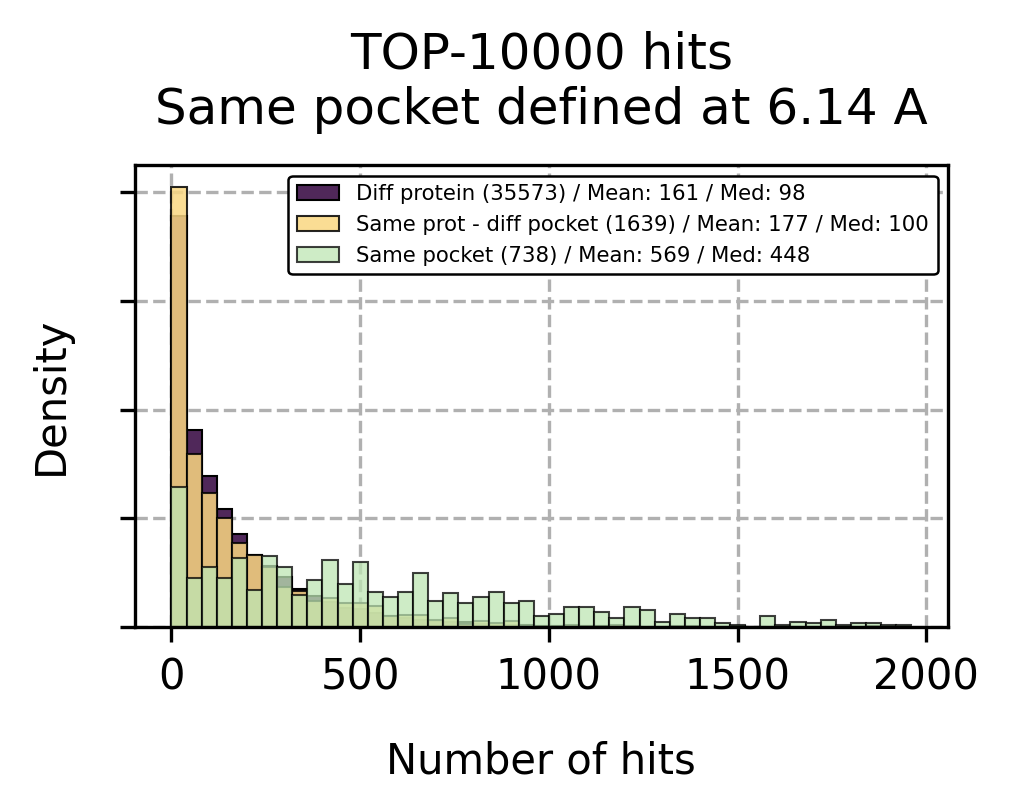

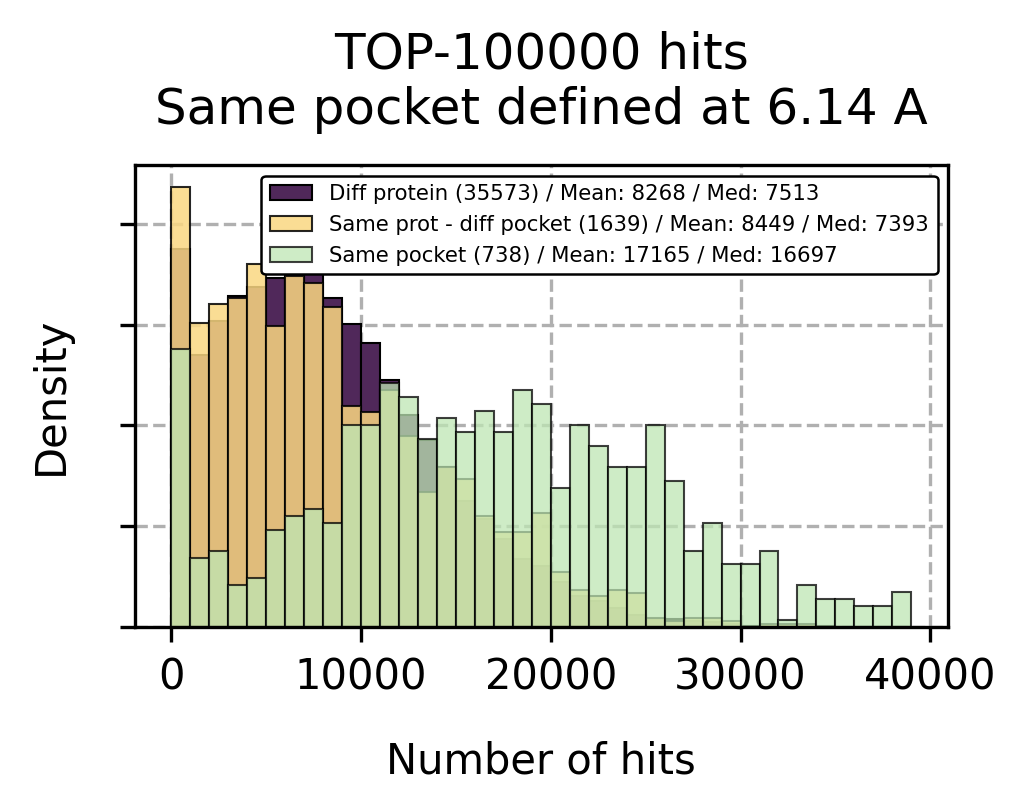

In [10]:
TOP_TO_BINS = {100: [i for i in range(0, 20, 1)],
               1000: [i for i in range(0, 30, 1)],
               10000: [i for i in range(0, 2000, 40)],
               100000: [i for i in range(0, 40000, 1000)]}

for TOP in TOPs:

    plt.figure(figsize=(3.5, 2))

    bins = TOP_TO_BINS[TOP]
    h1 = np.array(list(diff_protein[TOP].values()))
    h2 = np.array(list(same_protein[TOP].values()))
    h3 = np.array(list(same_pocket[TOP].values()))
    label1 = f'Diff protein ({len(diff_protein[TOP])}) / Mean: {int(np.mean(h1))} / Med: {int(np.median(h1))}'
    label2 = f'Same prot - diff pocket ({len(same_protein[TOP])}) / Mean: {int(np.mean(h2))} / Med: {int(np.median(h2))}'
    label3 = f'Same pocket ({len(same_pocket[TOP])}) / Mean: {int(np.mean(h3))} / Med: {int(np.median(h3))}'
    plt.hist(h1, bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=label1, zorder=2, density=True)
    plt.hist(h2, bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=label2, zorder=2, density=True, alpha=0.85)
    plt.hist(h3, bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=label3, zorder=2, density=True, alpha=0.75)

    title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
    plt.title(title, pad=10)
    plt.gca().set_yticklabels([])
    plt.xlabel("Number of hits", labelpad=10)
    plt.ylabel("Density", labelpad=8)
    plt.grid(linestyle='--', zorder=-2)
    l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
    l.get_frame().set_linewidth(0.6)
    plt.show()

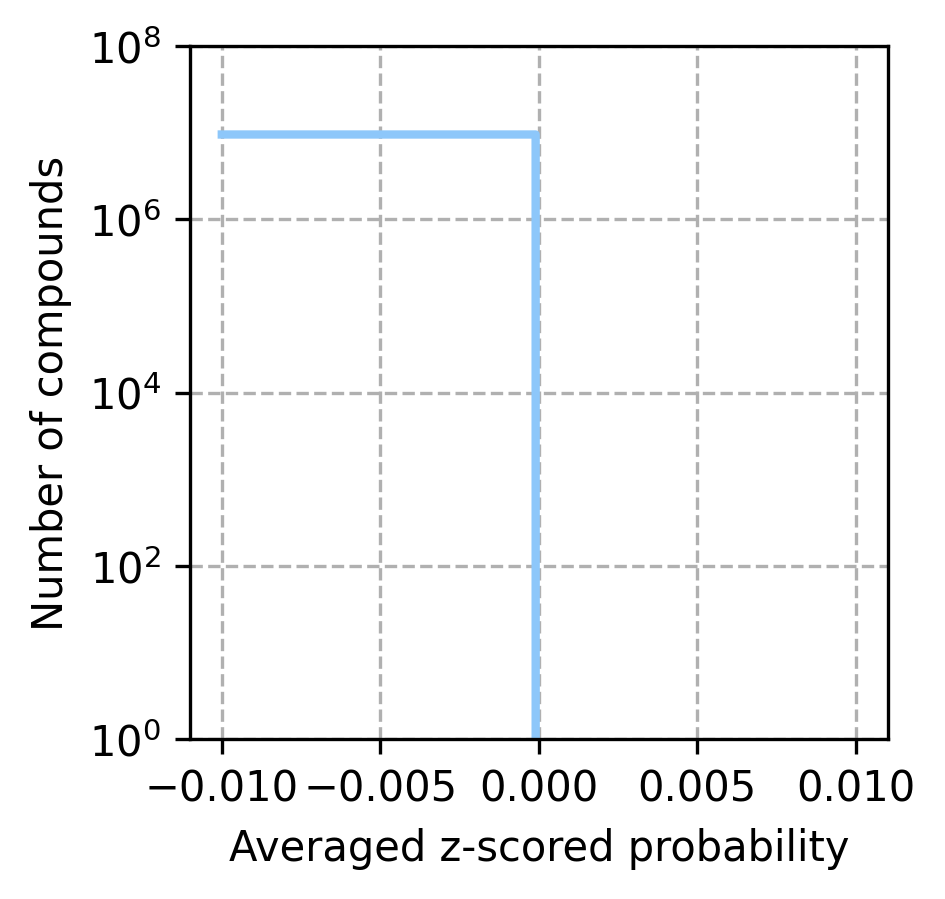

In [11]:
### PROBABILITY MATRIX

# Calculate average values
means = np.mean(M, axis=1)
# Define x space
xs = np.linspace(-0.01, 0.01, 100)
# Calculate # compounds having prob >= x
y = [np.where(means >= i)[0].shape[0] for i in xs]

plt.figure(figsize=(3, 3))
plt.plot(xs, y, c='#8DC7FA', lw=2)
plt.yscale('log')
plt.ylim([1, 1e8])
plt.grid(linestyle='--', zorder=-2)
plt.xlabel("Averaged z-scored probability")
plt.ylabel("Number of compounds")
plt.show()

In [12]:
from collections import Counter

In [13]:
### Study frequent hitters

TOPs = [100, 1000, 10000, 100000]
hits = {}
for top in TOPs:
    h = [i for pocket in pocket_to_inds for i in pocket_to_inds[pocket][:top]]
    hits[top] = dict(Counter(h))

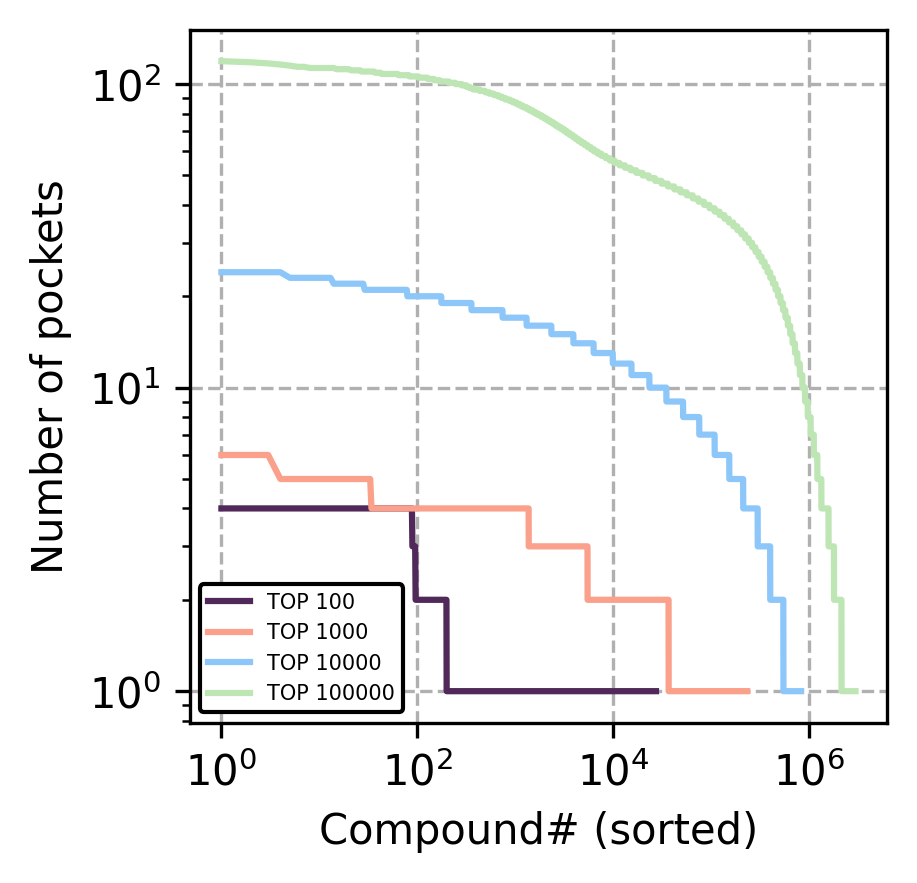

In [14]:
plt.figure(figsize=(3, 3))
colors = ['#50285A', '#FAA08B', '#8DC7FA', '#BEE6B4']
for c, top in zip(colors, TOPs):
    plt.plot([i+1 for i in range(len(hits[top]))], sorted(hits[top].values())[::-1], color=c, label=f'TOP {top}')
plt.grid(linestyle='--', zorder=-2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Compound# (sorted)")
plt.ylabel("Number of pockets")
plt.xticks([1, 100, 10000, 1000000])
plt.legend(prop={'size':5}, edgecolor='k', framealpha=1, loc='lower left')
plt.show()

In [ ]:
M